### Imports and Configuration

In [1]:
from pipeline_utils import make_case1_paths
import pandas as pd
import numpy as np

# Configure paths
paths = make_case1_paths()

PROJECT_DIR = paths["project"]
RAW_DIR = paths["raw_uhn"]
PROC_DIR = paths["proc"]
RESULTS_DIR = paths["results"]

print(f"Project directory: {PROJECT_DIR}")
print(f"Raw data directory: {RAW_DIR}")
print(f"Processed data directory: {PROC_DIR}")
print(f"Results directory: {RESULTS_DIR}")

# Input files
breast_fold_results = PROC_DIR / "growth_ml_fold_results_breast.csv"
breast_pred_results = PROC_DIR / "growth_ml_predictions_breast.csv"
breast_dt_rna_file = PROC_DIR / "rna_doubling_time_merged_breast.csv"

lung_fold_results = PROC_DIR / "growth_ml_fold_results_lung.csv"
lung_pred_results = PROC_DIR / "growth_ml_predictions_lung.csv"
lung_dt_rna_file = PROC_DIR / "rna_doubling_time_merged_lung.csv"

df_results_breast = pd.read_csv(breast_fold_results)
df_preds_breast = pd.read_csv(breast_pred_results)
df_dt_rna_breast = pd.read_csv(breast_dt_rna_file, index_col=0)

df_results_lung = pd.read_csv(lung_fold_results)
df_preds_lung = pd.read_csv(lung_pred_results)
df_dt_rna_lung = pd.read_csv(lung_dt_rna_file, index_col=0)

print(f"breast ML results file: {breast_fold_results}")
print(f"breast ML prediction file: {breast_pred_results}")
print(f"breast ML input file: {breast_dt_rna_file}")
print(f"lung ML results file: {lung_fold_results}")
print(f"lung ML prediction file: {lung_pred_results}")
print(f"lung ML input file: {lung_dt_rna_file}")

# Output files
roc_compare_plot = RESULTS_DIR / "figure2e_Model_Comparison.png"
roc_plot = RESULTS_DIR / "figure2f_ROC.png"
shap_breast_plot = RESULTS_DIR / "Figure2_SHAP_Compact_breast.png"
shap_breast_output = RESULTS_DIR / "SHAP_Global_Gene_Importance_breast.csv"
shap_lung_plot = RESULTS_DIR / "Figure2_SHAP_Compact_lung.png"
shap_lung_output = RESULTS_DIR / "SHAP_Global_Gene_Importance_lung.csv"


/Users/guanqiaofeng/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study
Raw data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/0_datasets
Processed data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate
Results directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate


breast ML results file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_ml_fold_results_breast.csv
breast ML prediction file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_ml_predictions_breast.csv
breast ML input file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/rna_doubling_time_merged_breast.csv
lung ML results file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_ml_fold_results_lung.csv
lung ML prediction file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_ml_predictions_lung.csv
lung ML input file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/rna_doubling_time_merged_lung.csv


### Model performance barplot

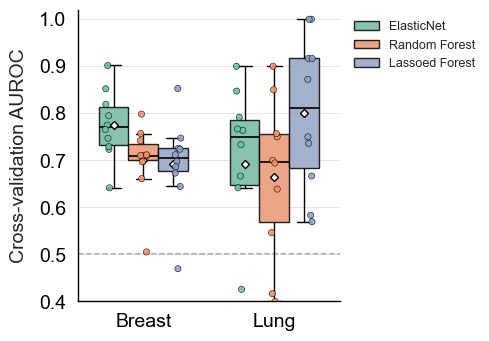

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Summarize fold AUROCs within each CV repeat before plotting
dataset_specs = {
    "Breast": {"results": df_results_breast, "n_splits": 5},
    "Lung": {"results": df_results_lung, "n_splits": 3},
}
model_names = ["ElasticNet", "RandomForest", "LassoedForest"]
model_labels = {
    "ElasticNet": "ElasticNet",
    "RandomForest": "Random Forest",
    "LassoedForest": "Lassoed Forest",
}
model_colors = {
    "ElasticNet": "#66c2a5",
    "RandomForest": "#fc8d62",
    "LassoedForest": "#8da0cb",
}

repeat_results = []
for dataset_name, spec in dataset_specs.items():
    tmp = spec["results"].loc[
        spec["results"]["Model"].isin(model_names),
        ["Model", "Fold", "AUROC"],
    ].dropna().copy()
    tmp["Repeat"] = ((tmp["Fold"].astype(int) - 1) // spec["n_splits"]) + 1
    tmp = tmp.groupby(["Repeat", "Model"], as_index=False)["AUROC"].mean()
    tmp["Dataset"] = dataset_name
    repeat_results.append(tmp)

plot_df = pd.concat(repeat_results, ignore_index=True)
plot_df["Model label"] = plot_df["Model"].map(model_labels)
palette = {model_labels[m]: model_colors[m] for m in model_names}
dataset_order = list(dataset_specs)
hue_order = [model_labels[m] for m in model_names]

# Nature-style box plots with every repeat-level value visible
sns.set_theme(style="whitegrid", context="paper", font="Arial")
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.boxplot(
    data=plot_df, x="Dataset", y="AUROC", hue="Model label",
    order=dataset_order, hue_order=hue_order, palette=palette,
    width=0.68, linewidth=1.0, showfliers=False, showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "white",
               "markeredgecolor": "black", "markersize": 4},
    boxprops={"edgecolor": "black", "linewidth": 1.0, "alpha": 0.85},
    whiskerprops={"color": "black", "linewidth": 1.0},
    capprops={"color": "black", "linewidth": 1.0},
    medianprops={"color": "black", "linewidth": 1.2}, ax=ax,
)
sns.stripplot(
    data=plot_df, x="Dataset", y="AUROC", hue="Model label",
    order=dataset_order, hue_order=hue_order, palette=palette,
    dodge=True, jitter=0.08, size=4.5, alpha=0.9,
    edgecolor="black", linewidth=0.4, legend=False, ax=ax, zorder=3,
)

ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.1,
           alpha=0.8, zorder=0)
ax.set_xlabel("")
ax.set_ylabel("Cross-validation AUROC", fontsize=14, labelpad=8)
ax.tick_params(axis="x", labelsize=14, colors="black", width=1.0)
ax.tick_params(axis="y", labelsize=14, colors="black", width=1.0)
ax.set_ylim(0.4, 1.02)
ax.legend(title="", loc="upper left", bbox_to_anchor=(1.01, 1.0),
          fontsize=9, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.7, alpha=0.7, zorder=0)

plt.tight_layout()
plt.savefig(roc_compare_plot, dpi=300, bbox_inches="tight")
plt.show()

### figure2f ROC

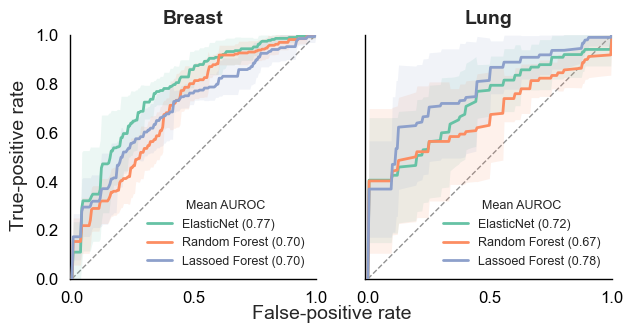

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Plot breast and lung ROC curves in separate, directly comparable panels
dataset_specs = {
    "Breast": {"predictions": df_preds_breast, "n_splits": 5},
    "Lung": {"predictions": df_preds_lung, "n_splits": 3},
}
model_names = ["ElasticNet", "RandomForest", "LassoedForest"]
model_labels = {
    "ElasticNet": "ElasticNet",
    "RandomForest": "Random Forest",
    "LassoedForest": "Lassoed Forest",
}
colors = {
    "ElasticNet": "#66c2a5",
    "RandomForest": "#fc8d62",
    "LassoedForest": "#8da0cb",
}
mean_fpr = np.linspace(0, 1, 200)

sns.set_theme(style="white", context="paper", font="Arial")
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), sharex=True, sharey=True)

for ax, (dataset_name, spec) in zip(axes, dataset_specs.items()):
    pred_df = spec["predictions"].copy()
    pred_df["Repeat"] = (
        (pred_df["Fold"].astype(int) - 1) // spec["n_splits"]
    ) + 1

    for model_name in model_names:
        model_df = pred_df[pred_df["Model"] == model_name]
        repeat_tprs = []
        repeat_aucs = []

        for repeat in sorted(model_df["Repeat"].unique()):
            repeat_df = model_df[model_df["Repeat"] == repeat]
            if repeat_df["True_Label"].nunique() < 2:
                continue

            fpr, tpr, _ = roc_curve(
                repeat_df["True_Label"], repeat_df["Prob_Slow"]
            )
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            interp_tpr[-1] = 1.0
            repeat_tprs.append(interp_tpr)
            repeat_aucs.append(auc(fpr, tpr))

        repeat_tprs = np.asarray(repeat_tprs)
        mean_tpr = repeat_tprs.mean(axis=0)
        tpr_sd = repeat_tprs.std(axis=0, ddof=1)
        mean_auc = np.mean(repeat_aucs)

        ax.plot(
            mean_fpr, mean_tpr, color=colors[model_name], linewidth=2.0,
            label=f"{model_labels[model_name]} ({mean_auc:.2f})", zorder=3,
        )
        ax.fill_between(
            mean_fpr, np.maximum(mean_tpr - tpr_sd, 0),
            np.minimum(mean_tpr + tpr_sd, 1),
            color=colors[model_name], alpha=0.12, linewidth=0, zorder=1,
        )

    ax.plot([0, 1], [0, 1], linestyle="--", color="#777777",
            linewidth=1.0, alpha=0.8, zorder=0)
    ax.set_title(dataset_name, fontsize=14, fontweight="bold", pad=8)
    ax.set_xlim(-0.01, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(axis="both", labelsize=12, colors="black", width=1.0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.legend(loc="lower right", fontsize=9, frameon=False,
              title="Mean AUROC", title_fontsize=9)

fig.supxlabel("False-positive rate", fontsize=14, y=0.02)
fig.supylabel("True-positive rate", fontsize=14, x=0.04)
#plt.tight_layout(rect=[0.01, 0.01, 1, 1])
plt.savefig(roc_plot, dpi=400, bbox_inches="tight")
plt.savefig(roc_plot.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

### SHAP analysis for RF -- breast

Breast: 99 of 161 genes have selection_frequency >= 50%


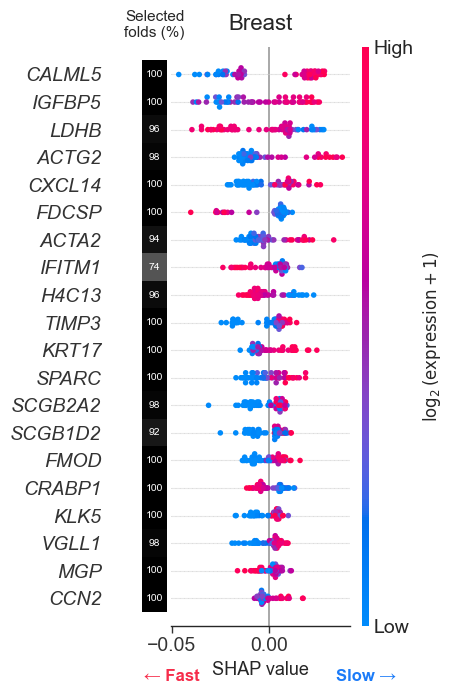

Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/Figure2_SHAP_Compact_breast.png and /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/SHAP_Global_Gene_Importance_breast.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

SHAP_TOP_N = 20
SHAP_RANK_METRIC = "mean_abs_shap_all_test_predictions"
SHAP_MIN_NONZERO_FREQUENCY = 0.50

def prepare_cv_shap(raw_path, summary_path, expression_df, top_n=SHAP_TOP_N,
                     min_nonzero_frequency=SHAP_MIN_NONZERO_FREQUENCY, label=None):
    """Build one held-out-CV SHAP profile per PDX model."""
    raw = pd.read_csv(raw_path)
    summary = pd.read_csv(summary_path)
    raw["ModelID"] = raw["ModelID"].astype(str)

    eligible = summary.loc[summary["selection_frequency"] >= min_nonzero_frequency].copy()
    prefix = f"{label}: " if label else ""
    if len(eligible) < top_n:
        raise ValueError(
            f"{prefix}only {len(eligible)} genes have selection_frequency >= "
            f"{min_nonzero_frequency:.0%}; cannot plot top {top_n}."
        )
    print(f"{prefix}{len(eligible)} of {len(summary)} genes have selection_frequency "
          f">= {min_nonzero_frequency:.0%}")

    # This ranking includes zero contribution in folds where a gene was not selected.
    top_genes = (eligible.sort_values(SHAP_RANK_METRIC, ascending=False)
                         .head(top_n)["Gene"].tolist())

    # Retain every held-out fold/model prediction, even if none of the top genes
    # entered that fold's RF. An absent gene has exactly zero contribution.
    complete_index = pd.MultiIndex.from_frame(
        raw[["Fold", "ModelID"]].drop_duplicates()
    )
    fold_model_shap = (
        raw.loc[raw["Gene"].isin(top_genes)]
           .pivot_table(index=["Fold", "ModelID"], columns="Gene",
                        values="SHAP_Slow", aggfunc="first")
           .reindex(index=complete_index, columns=top_genes)
           .fillna(0.0)
    )

    # Repeated CV can predict a PDX more than once; average first to avoid pseudo-replication.
    model_shap = fold_model_shap.groupby(level="ModelID").mean()
    expression = expression_df.drop(columns=["doubling_time_days"]).copy()
    expression.index = expression.index.astype(str)

    missing_models = model_shap.index.difference(expression.index)
    missing_genes = pd.Index(top_genes).difference(expression.columns)
    if len(missing_models) or len(missing_genes):
        raise ValueError(f"Missing models: {missing_models.tolist()}; missing genes: {missing_genes.tolist()}")

    model_expression = expression.loc[model_shap.index, top_genes]
    return raw, summary, model_shap, model_expression

def add_selection_frequency_panel(fig, ax, summary):
    """Add a fold-selection-frequency strip aligned with SHAP gene rows."""
    frequency_by_gene = summary.set_index("Gene")["selection_frequency"]
    displayed_genes = [label.get_text() for label in ax.get_yticklabels()]
    frequencies = frequency_by_gene.reindex(displayed_genes).to_numpy(dtype=float)
    if np.isnan(frequencies).any():
        missing = np.asarray(displayed_genes)[np.isnan(frequencies)].tolist()
        raise ValueError(f"Selection frequency is missing for: {missing}")

    # The extra y-label padding reserves this space between gene names and beeswarm.
    position = ax.get_position()
    panel_width = 0.055
    panel_gap = 0.008
    frequency_ax = fig.add_axes([
        position.x0 - panel_width - panel_gap, position.y0,
        panel_width, position.height,
    ])
    frequency_ax.imshow(
        frequencies[:, None], cmap="Greys", vmin=0, vmax=1,
        origin="lower", aspect="auto",
        extent=(-0.5, 0.5, -0.5, len(frequencies) - 0.5),
    )
    frequency_ax.set_ylim(ax.get_ylim())

    for row, frequency in enumerate(frequencies):
        text_color = "white" if frequency >= 0.55 else "black"
        frequency_ax.text(
            0, row, f"{100 * frequency:.0f}", ha="center", va="center",
            fontsize=7.5, color=text_color,
        )

    frequency_ax.set_title("Selected\nfolds (%)", fontsize=11, pad=7)
    frequency_ax.set_xticks([])
    frequency_ax.set_yticks([])
    for spine in frequency_ax.spines.values():
        spine.set_visible(False)
    return frequency_ax

breast_shap_raw, breast_shap_summary, breast_model_shap, breast_model_expression = prepare_cv_shap(
    PROC_DIR / "growth_rf_shap_values_breast.csv",
    PROC_DIR / "growth_rf_shap_summary_breast.csv",
    df_dt_rna_breast,
    label="Breast",
)
shap_val_slow = breast_model_shap.to_numpy()
X_ext_hvg = breast_model_expression
# print(f"Breast: {len(X_ext_hvg)} PDX models aggregated from "
#       f"{breast_shap_raw['Fold'].nunique()} held-out CV folds.")

# 1. Tighter Figure Size (Tall and Narrower)
fig = plt.figure(figsize=(4.5, 7)) 

# 2. Plot with Plot_Size=None to prevent SHAP from overriding your figsize
shap.summary_plot(
    shap_val_slow, 
    X_ext_hvg, 
    max_display=len(X_ext_hvg.columns), 
    plot_size=None, 
    show=False,
    color_bar_label=r"$\log_2(\mathrm{expression}+1)$"
)

# 3. INCREASE COLOR BAR FONT SIZE
# SHAP creates the color bar as the last axes in the figure
cb_ax = fig.axes[-1] 
cb_ax.set_ylabel(r"$\log_2(\mathrm{expression}+1)$", fontsize=12, labelpad=5)
cb_ax.tick_params(labelsize=14) # Tick size (Low/High)

# 3. ITALIZE GENE NAMES (Standard for Papers)
# This also makes the labels feel more "dense" and professional
for label in plt.gca().get_yticklabels():
    label.set_fontstyle("italic")

# 4. TIGHTEN THE LAYOUT
plt.title("Breast", fontsize=16, pad=12)
plt.xlabel("SHAP value", fontsize=13)
# Manual Labels for Clarity
plt.text(-0.05, -3, "← Fast", color="#f62c4a", fontweight='bold', ha='center', fontsize=12)
plt.text(0.05, -3, "Slow →", color="#1b7bf8", fontweight='bold', ha='center', fontsize=12)


# Optional: Horizontal grid to separate gene rows
ax = plt.gca()
ax.grid(True, axis='y', color='lightgray', linestyle='-', alpha=0.5, zorder=0)

# Adjust tick label sizes for the compact view
ax.tick_params(axis='x', which='major', labelsize=14)
ax.tick_params(axis='y', which='major', labelsize=14, pad=30)

# 5. REMOVE EXTRA PADDING
plt.tight_layout(pad=1.0)
breast_frequency_ax = add_selection_frequency_panel(fig, ax, breast_shap_summary)
plt.savefig(shap_breast_plot, dpi=600, bbox_inches='tight')
plt.savefig(shap_breast_plot.with_suffix(".pdf"), bbox_inches='tight')
plt.show()

# Export the same stability-aware CV ranking used to select the displayed genes.
breast_shap_summary.to_csv(shap_breast_output, index=False)
print(f"Saved {shap_breast_plot} and {shap_breast_output}")

### SHAP analysis for RF -- lung

Lung: 600 of 1248 genes have selection_frequency >= 50%


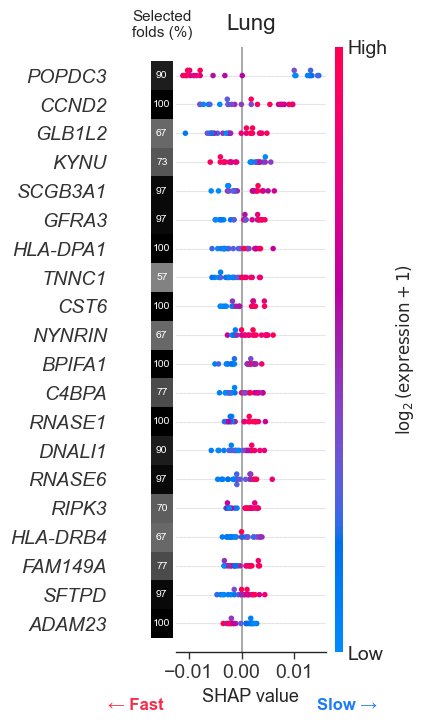

Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/Figure2_SHAP_Compact_lung.png and /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/SHAP_Global_Gene_Importance_lung.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

lung_shap_raw, lung_shap_summary, lung_model_shap, lung_model_expression = prepare_cv_shap(
    PROC_DIR / "growth_rf_shap_values_lung.csv",
    PROC_DIR / "growth_rf_shap_summary_lung.csv",
    df_dt_rna_lung,
    label="Lung",
)
shap_val_slow = lung_model_shap.to_numpy()
X_ext_hvg = lung_model_expression
# print(f"Lung: {len(X_ext_hvg)} PDX models aggregated from "
#       f"{lung_shap_raw['Fold'].nunique()} held-out CV folds.")

# 1. Tighter Figure Size (Tall and Narrower)
fig = plt.figure(figsize=(4, 7)) 

# 2. Plot with Plot_Size=None to prevent SHAP from overriding your figsize
shap.summary_plot(
    shap_val_slow, 
    X_ext_hvg, 
    max_display=len(X_ext_hvg.columns), 
    plot_size=None, 
    show=False,
    color_bar_label=r"$\log_2(\mathrm{expression}+1)$"
)

# 3. INCREASE COLOR BAR FONT SIZE
# SHAP creates the color bar as the last axes in the figure
cb_ax = fig.axes[-1] 
cb_ax.set_ylabel(r"$\log_2(\mathrm{expression}+1)$", fontsize=12, labelpad=5)
cb_ax.tick_params(labelsize=14) # Tick size (Low/High)

# 3. ITALIZE GENE NAMES (Standard for Papers)
# This also makes the labels feel more "dense" and professional
for label in plt.gca().get_yticklabels():
    label.set_fontstyle("italic")

# 4. TIGHTEN THE LAYOUT
plt.title("Lung", fontsize=16, pad=12)
plt.xlabel("SHAP value", fontsize=13)
# Manual Labels for Clarity
plt.text(-0.02, -3, "← Fast", color="#f62c4a", fontweight='bold', ha='center', fontsize=12)
plt.text(0.02, -3, "Slow →", color="#1b7bf8", fontweight='bold', ha='center', fontsize=12)


# Optional: Horizontal grid to separate gene rows
ax = plt.gca()
ax.grid(True, axis='y', color='lightgray', linestyle='-', alpha=0.5, zorder=0)

# Adjust tick label sizes for the compact view
ax.tick_params(axis='x', which='major', labelsize=14)
ax.tick_params(axis='y', which='major', labelsize=14, pad=30)

# 5. REMOVE EXTRA PADDING
plt.tight_layout(pad=0)
lung_frequency_ax = add_selection_frequency_panel(fig, ax, lung_shap_summary)
plt.savefig(shap_lung_plot, dpi=600, bbox_inches='tight')
plt.savefig(shap_lung_plot.with_suffix(".pdf"), bbox_inches='tight')
plt.show()

# Export the same stability-aware CV ranking used to select the displayed genes.
lung_shap_summary.to_csv(shap_lung_output, index=False)
print(f"Saved {shap_lung_plot} and {shap_lung_output}")

### Shared SHAP genes: breast versus lung

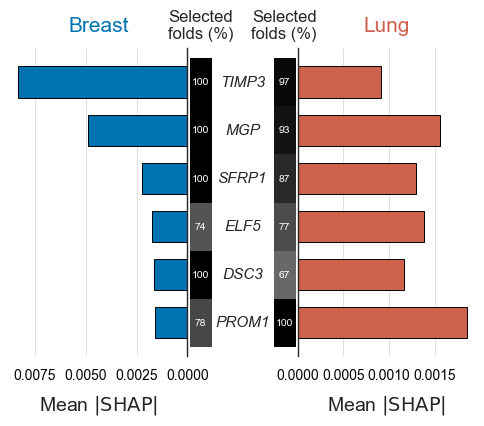

Shared genes between the two top-100 SHAP lists: 6
Displayed genes: 6 top genes ranked by breast importance
Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/Figure2_SHAP_Shared_Genes_breast_lung.png and /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/SHAP_Shared_Gene_Importance_breast_lung.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

N_TOP_PER_COHORT = 100
IMPORTANCE_METRIC = "mean_abs_shap_all_test_predictions"
MIN_NONZERO_FREQUENCY = 0.50
shared_shap_plot = RESULTS_DIR / "Figure2_SHAP_Shared_Genes_breast_lung.png"
shared_shap_output = RESULTS_DIR / "SHAP_Shared_Gene_Importance_breast_lung.csv"

breast_summary = pd.read_csv(PROC_DIR / "growth_rf_shap_summary_breast.csv")
lung_summary = pd.read_csv(PROC_DIR / "growth_rf_shap_summary_lung.csv")

# Restrict to genes selected into the RF in at least half of completed folds,
# then define each cohort's SHAP list using its top 100 stability-aware genes.
breast_eligible = breast_summary.loc[breast_summary["selection_frequency"] >= MIN_NONZERO_FREQUENCY]
lung_eligible = lung_summary.loc[lung_summary["selection_frequency"] >= MIN_NONZERO_FREQUENCY]
breast_top = breast_eligible.nlargest(
    min(N_TOP_PER_COHORT, len(breast_eligible)), IMPORTANCE_METRIC
)
lung_top = lung_eligible.nlargest(
    min(N_TOP_PER_COHORT, len(lung_eligible)), IMPORTANCE_METRIC
)

shared = (
    breast_top[["Gene", IMPORTANCE_METRIC, "selection_frequency"]]
    .merge(
        lung_top[["Gene", IMPORTANCE_METRIC, "selection_frequency"]],
        on="Gene", how="inner", suffixes=("_breast", "_lung"),
    )
)
if shared.empty:
    raise ValueError("No genes overlap between the two top-150 SHAP lists.")

breast_importance = f"{IMPORTANCE_METRIC}_breast"
lung_importance = f"{IMPORTANCE_METRIC}_lung"

# Select genes important in both cohorts without allowing the cohort with the
# larger absolute SHAP scale to dominate the displayed-gene ranking.
shared["breast_importance_percentile"] = shared[breast_importance].rank(pct=True)
shared["lung_importance_percentile"] = shared[lung_importance].rank(pct=True)
shared["balanced_importance_rank"] = (
    shared["breast_importance_percentile"]
    + shared["lung_importance_percentile"]
) / 2

# Display every shared gene, ordered by breast mean absolute SHAP.
# Ascending order places the largest breast bar at the top of a horizontal plot.
N_DISPLAY_GENES = 15
shared_plot_data = (
    shared.nlargest(N_DISPLAY_GENES, breast_importance)
    .sort_values(breast_importance, ascending=True)
)
shared.sort_values(breast_importance, ascending=False).to_csv(
    shared_shap_output, index=False
)

# Butterfly layout: raw held-out mean |SHAP| values are shown on cohort-specific axes.
fig = plt.figure(figsize=(6, 4))
grid = fig.add_gridspec(
    1, 5, width_ratios=[1, 0.12, 0.32, 0.12, 1], wspace=0.03
)
ax_breast = fig.add_subplot(grid[0, 0])
ax_breast_frequency = fig.add_subplot(grid[0, 1])
ax_gene = fig.add_subplot(grid[0, 2])
ax_lung_frequency = fig.add_subplot(grid[0, 3])
ax_lung = fig.add_subplot(grid[0, 4])

y = np.arange(len(shared_plot_data))
bar_style = dict(height=0.65, edgecolor="black", linewidth=0.7)
ax_breast.barh(y, shared_plot_data[breast_importance], color="#0072B2", **bar_style)
ax_lung.barh(y, shared_plot_data[lung_importance], color="#CF624F", **bar_style)
ax_breast.invert_xaxis()

for row, gene in enumerate(shared_plot_data["Gene"]):
    ax_gene.text(0.5, row, gene, ha="center", va="center",
                 fontsize=11, fontstyle="italic")

def draw_selection_frequency_strip(axis, frequencies):
    """Draw a grayscale fold-selection strip aligned with the gene rows."""
    frequencies = np.asarray(frequencies, dtype=float)
    axis.imshow(
        frequencies[:, None], cmap="Greys", vmin=0, vmax=1,
        origin="lower", aspect="auto",
        extent=(-0.5, 0.5, -0.5, len(frequencies) - 0.5),
    )
    for row, frequency in enumerate(frequencies):
        text_color = "white" if frequency >= 0.55 else "black"
        axis.text(0, row, f"{100 * frequency:.0f}",
                  ha="center", va="center", fontsize=7.5, color=text_color)
    axis.set_title("Selected\nfolds (%)", fontsize=12, pad=7)
    axis.set_xticks([])
    axis.set_yticks([])
    for spine in axis.spines.values():
        spine.set_visible(False)

draw_selection_frequency_strip(
    ax_breast_frequency, shared_plot_data["selection_frequency_breast"]
)
draw_selection_frequency_strip(
    ax_lung_frequency, shared_plot_data["selection_frequency_lung"]
)

for axis in (ax_breast, ax_breast_frequency, ax_gene, ax_lung_frequency, ax_lung):
    axis.set_ylim(-0.7, len(shared_plot_data) - 0.3)

ax_gene.set_xlim(0, 1)
ax_gene.set_xticks([])
ax_gene.set_yticks([])
for spine in ax_gene.spines.values():
    spine.set_visible(False)

for axis in (ax_breast, ax_lung):
    axis.set_yticks([])
    #axis.axvline(0, color="black", linewidth=1.0)
    axis.grid(axis="x", color="#D9D9D9", linewidth=0.7, alpha=0.8)
    axis.set_axisbelow(True)
    axis.tick_params(axis="x", labelsize=10, colors="black")
    axis.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.4f}"))
    axis.spines["top"].set_visible(False)
    axis.spines["left"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["bottom"].set_visible(False)

# After inversion, the breast panel's physical right edge is x = 0.
ax_breast.spines["right"].set_visible(True)
ax_lung.spines["left"].set_visible(True)


ax_breast.set_title("Breast", fontsize=15, pad=12, color="#0072B2")
ax_lung.set_title("Lung", fontsize=15, pad=12, color="#CF624F")
ax_breast.set_xlabel(r"Mean $|\mathrm{SHAP}|$", fontsize=14, labelpad=8)
ax_lung.set_xlabel(r"Mean $|\mathrm{SHAP}|$", fontsize=14, labelpad=8)
#fig.suptitle("Shared top-150 RF features across cohorts", fontsize=17, y=1.01)
# fig.text(0.5, -0.02,
#          "Genes ranked by balanced within-cohort importance; bars show raw held-out CV importance",
#          ha="center", fontsize=9)

plt.savefig(shared_shap_plot, dpi=600, bbox_inches="tight")
plt.savefig(shared_shap_plot.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

print(f"Shared genes between the two top-{N_TOP_PER_COHORT} SHAP lists: {len(shared)}")
print(f"Displayed genes: {len(shared_plot_data)} top genes ranked by breast importance")
print(f"Saved {shared_shap_plot} and {shared_shap_output}")

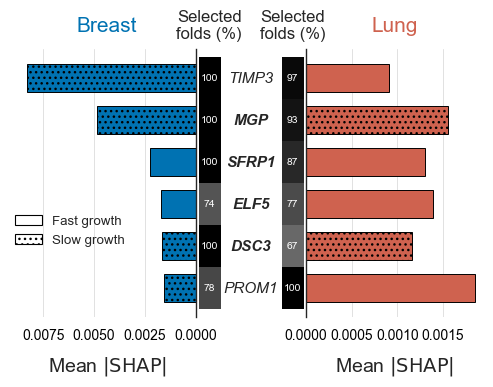

Direction-concordant genes among the 6 shared: 4
Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/Figure2_SHAP_Shared_Genes_breast_lung_direction.png


In [7]:
# Alternative version: bars hatched by growth direction, gene name bolded when
# breast and lung agree on direction. Reuses breast_top/lung_top/IMPORTANCE_METRIC/
# breast_importance/lung_importance/N_DISPLAY_GENES from the cell above.
from matplotlib.patches import Patch

shared_shap_dir_plot = RESULTS_DIR / "Figure2_SHAP_Shared_Genes_breast_lung_direction.png"

shared_dir = (
    breast_top[["Gene", IMPORTANCE_METRIC, "selection_frequency", "mean_shap_all_test_predictions"]]
    .merge(
        lung_top[["Gene", IMPORTANCE_METRIC, "selection_frequency", "mean_shap_all_test_predictions"]],
        on="Gene", how="inner", suffixes=("_breast", "_lung"),
    )
)
# Positive mean SHAP -> slow growth; negative -> fast growth (same convention used throughout).
shared_dir["direction_breast"] = np.where(
    shared_dir["mean_shap_all_test_predictions_breast"] > 0, "Slow", "Fast"
)
shared_dir["direction_lung"] = np.where(
    shared_dir["mean_shap_all_test_predictions_lung"] > 0, "Slow", "Fast"
)
shared_dir["direction_concordant"] = shared_dir["direction_breast"] == shared_dir["direction_lung"]

shared_plot_data_dir = (
    shared_dir.nlargest(N_DISPLAY_GENES, breast_importance)
    .sort_values(breast_importance, ascending=True)
)

fig = plt.figure(figsize=(6, 4.8))
grid = fig.add_gridspec(
    1, 5, width_ratios=[1, 0.12, 0.32, 0.12, 1], wspace=0.03
)
ax_breast = fig.add_subplot(grid[0, 0])
ax_breast_frequency = fig.add_subplot(grid[0, 1])
ax_gene = fig.add_subplot(grid[0, 2])
ax_lung_frequency = fig.add_subplot(grid[0, 3])
ax_lung = fig.add_subplot(grid[0, 4])

bar_style = dict(height=0.65, edgecolor="black", linewidth=0.7)
direction_hatch = {"Slow": "...", "Fast": ""}

for row, (value, direction) in enumerate(
    zip(shared_plot_data_dir[breast_importance], shared_plot_data_dir["direction_breast"])
):
    ax_breast.barh(row, value, color="#0072B2", hatch=direction_hatch[direction], **bar_style)
for row, (value, direction) in enumerate(
    zip(shared_plot_data_dir[lung_importance], shared_plot_data_dir["direction_lung"])
):
    ax_lung.barh(row, value, color="#CF624F", hatch=direction_hatch[direction], **bar_style)
ax_breast.invert_xaxis()

for row, (gene, concordant) in enumerate(
    zip(shared_plot_data_dir["Gene"], shared_plot_data_dir["direction_concordant"])
):
    ax_gene.text(
        0.5, row, gene, ha="center", va="center", fontsize=11,
        fontstyle="italic", fontweight="bold" if concordant else "normal",
    )

def draw_selection_frequency_strip(axis, frequencies):
    """Draw a grayscale fold-selection strip aligned with the gene rows."""
    frequencies = np.asarray(frequencies, dtype=float)
    axis.imshow(
        frequencies[:, None], cmap="Greys", vmin=0, vmax=1,
        origin="lower", aspect="auto",
        extent=(-0.5, 0.5, -0.5, len(frequencies) - 0.5),
    )
    for row, frequency in enumerate(frequencies):
        text_color = "white" if frequency >= 0.55 else "black"
        axis.text(0, row, f"{100 * frequency:.0f}",
                  ha="center", va="center", fontsize=7.5, color=text_color)
    axis.set_title("Selected\nfolds (%)", fontsize=12, pad=7)
    axis.set_xticks([])
    axis.set_yticks([])
    for spine in axis.spines.values():
        spine.set_visible(False)

draw_selection_frequency_strip(
    ax_breast_frequency, shared_plot_data_dir["selection_frequency_breast"]
)
draw_selection_frequency_strip(
    ax_lung_frequency, shared_plot_data_dir["selection_frequency_lung"]
)

for axis in (ax_breast, ax_breast_frequency, ax_gene, ax_lung_frequency, ax_lung):
    axis.set_ylim(-0.7, len(shared_plot_data_dir) - 0.3)

ax_gene.set_xlim(0, 1)
ax_gene.set_xticks([])
ax_gene.set_yticks([])
for spine in ax_gene.spines.values():
    spine.set_visible(False)

for axis in (ax_breast, ax_lung):
    axis.set_yticks([])
    axis.grid(axis="x", color="#D9D9D9", linewidth=0.7, alpha=0.8)
    axis.set_axisbelow(True)
    axis.tick_params(axis="x", labelsize=10, colors="black")
    axis.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.4f}"))
    axis.spines["top"].set_visible(False)
    axis.spines["left"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["bottom"].set_visible(False)

ax_breast.spines["right"].set_visible(True)
ax_lung.spines["left"].set_visible(True)

ax_breast.set_title("Breast", fontsize=15, pad=12, color="#0072B2")
ax_lung.set_title("Lung", fontsize=15, pad=12, color="#CF624F")
ax_breast.set_xlabel(r"Mean $|\mathrm{SHAP}|$", fontsize=14, labelpad=8)
ax_lung.set_xlabel(r"Mean $|\mathrm{SHAP}|$", fontsize=14, labelpad=8)

# Manual margins (not tight_layout, which mishandles this gridspec) leave room
# below the axes for the direction legend and concordance note.
fig.subplots_adjust(bottom=0.32, top=0.88)

legend_handles = [
    Patch(facecolor="white", edgecolor="black", hatch="", label="Fast growth"),
    Patch(facecolor="white", edgecolor="black", hatch="...", label="Slow growth"),
]
fig.legend(
    handles=legend_handles, loc="center left", ncol = 1, frameon=False,
    fontsize=9.5, bbox_to_anchor=(0.1, 0.50),
)

plt.savefig(shared_shap_dir_plot, dpi=600)
plt.savefig(shared_shap_dir_plot.with_suffix(".pdf"))
plt.show()

n_concordant = int(shared_dir["direction_concordant"].sum())
print(f"Direction-concordant genes among the {len(shared_dir)} shared: {n_concordant}")
print(f"Saved {shared_shap_dir_plot}")

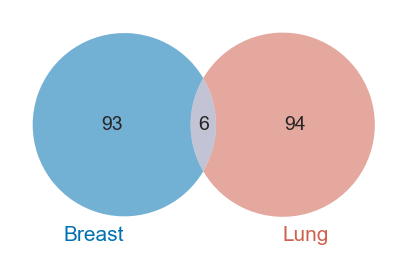

Breast-only: 93; Lung-only: 94; Shared: 6
Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/Figure2_SHAP_Venn_breast_lung.png


In [8]:
from matplotlib_venn import venn2

venn_plot = RESULTS_DIR / "Figure2_SHAP_Venn_breast_lung.png"

shared_genes = sorted(shared["Gene"])
breast_only = len(breast_top) - len(shared_genes)
lung_only = len(lung_top) - len(shared_genes)

fig, ax = plt.subplots(figsize=(5, 4))
venn = venn2(
    subsets=(breast_only, lung_only, len(shared_genes)),
    set_labels=("Breast", "Lung"),
    set_colors=("#0072B2", "#CF624F"),
    alpha=0.55,
    ax=ax,
)
venn.get_label_by_id("A").set_color("#0072B2")
venn.get_label_by_id("B").set_color("#CF624F")
for label_id in ("A", "B"):
    venn.get_label_by_id(label_id).set_fontsize(15)
for subset_id in ("10", "01", "11"):
    label = venn.get_label_by_id(subset_id)
    if label is not None:
        label.set_fontsize(14)

plt.savefig(venn_plot, dpi=600, bbox_inches="tight")
plt.savefig(venn_plot.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

print(f"Breast-only: {breast_only}; Lung-only: {lung_only}; Shared: {len(shared_genes)}")
print(f"Saved {venn_plot}")

### ElasticNet coefficients -- breast

Breast: 18 of 161 genes have non-zero coefficients in >= 50% of completed folds


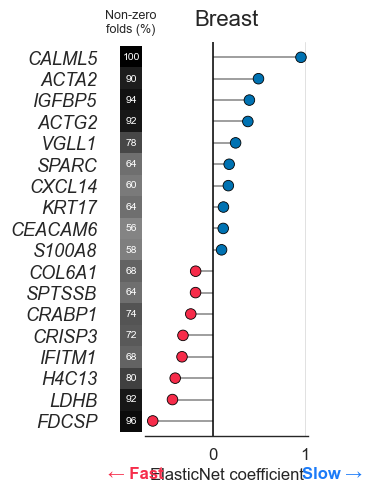

Loaded /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_elasticnet_coefficient_summary_breast.csv
Breast ElasticNet: 50 completed folds; plotted top 18 genes with >= 50% non-zero-fold frequency; saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/Figure2_ElasticNet_Coefficients_breast.png


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

EN_TOP_N = 20
EN_MIN_NONZERO_FREQUENCY = 0.50

def plot_elasticnet_cv_coefficients(
    summary, cohort, output_path, top_n=EN_TOP_N,
    min_nonzero_frequency=EN_MIN_NONZERO_FREQUENCY,
):
    eligible = summary.loc[
        summary["nonzero_frequency"] >= min_nonzero_frequency
    ].copy()
    print(
        f"{cohort}: {len(eligible)} of {len(summary)} genes have non-zero "
        f"coefficients in >= {min_nonzero_frequency:.0%} of completed folds"
    )
    top = (eligible.nlargest(min(top_n, len(eligible)), "abs_mean_standardized_coefficient")
                  .sort_values("mean_standardized_coefficient"))
    values = top["mean_standardized_coefficient"].to_numpy()
    frequencies = top["nonzero_frequency"].to_numpy()
    y = np.arange(len(top))

    fig, ax = plt.subplots(figsize=(4, 5))
    ax.hlines(y, 0, values, color="#9E9E9E", linewidth=1.4, zorder=1)
    colors = np.where(values < 0, "#f62c4a", "#0072B2")
    ax.scatter(values, y, c=colors, s=58, edgecolor="black", linewidth=0.6, zorder=2)
    ax.axvline(0, color="black", linewidth=1.1)
    ax.set_yticks(y, top["Gene"])
    for label in ax.get_yticklabels():
        label.set_fontstyle("italic")
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=13, pad=30)
    ax.set_ylim(-0.7, len(top) - 0.3)
    ax.set_xlabel("ElasticNet coefficient", fontsize=12)
    # Manual Labels for Clarity
    plt.text(min(values)*1.2-0.05, -2.7, "← Fast", color="#f62c4a", fontweight='bold', ha='center', fontsize=12)
    plt.text(max(values)*1.3+0.05, -2.7, "Slow →", color="#1b7bf8", fontweight='bold', ha='center', fontsize=12)

    ax.set_title(cohort, fontsize=16, pad=12)
    ax.grid(axis="x", color="#D9D9D9", linewidth=0.7, alpha=0.8)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    plt.tight_layout(pad=1.0)

    position = ax.get_position()
    frequency_ax = fig.add_axes([position.x0 - 0.063, position.y0, 0.055, position.height])
    frequency_ax.imshow(
        frequencies[:, None], cmap="Greys", vmin=0, vmax=1,
        origin="lower", aspect="auto",
        extent=(-0.5, 0.5, -0.5, len(frequencies) - 0.5),
    )
    frequency_ax.set_ylim(ax.get_ylim())
    for row, frequency in enumerate(frequencies):
        text_color = "white" if frequency >= 0.55 else "black"
        frequency_ax.text(0, row, f"{100 * frequency:.0f}", ha="center",
                          va="center", fontsize=7.5, color=text_color)
    frequency_ax.set_title("Non-zero\nfolds (%)", fontsize=9, pad=7)
    frequency_ax.set_xticks([])
    frequency_ax.set_yticks([])
    for spine in frequency_ax.spines.values():
        spine.set_visible(False)

    plt.savefig(output_path, dpi=600, bbox_inches="tight")
    plt.savefig(output_path.with_suffix(".pdf"), bbox_inches="tight")
    plt.show()
    return top


breast_en_summary_file = PROC_DIR / "growth_elasticnet_coefficient_summary_breast.csv"
breast_en_summary = pd.read_csv(breast_en_summary_file)

breast_en_plot = RESULTS_DIR / "Figure2_ElasticNet_Coefficients_breast.png"
breast_en_top = plot_elasticnet_cv_coefficients(
    breast_en_summary,
    cohort="Breast",
    output_path=breast_en_plot,
    top_n=EN_TOP_N,
)

n_breast_en_folds = int(breast_en_summary["n_completed_folds"].iloc[0])
print(f"Loaded {breast_en_summary_file}")
print(f"Breast ElasticNet: {n_breast_en_folds} completed folds; plotted top {len(breast_en_top)} genes with >= {EN_MIN_NONZERO_FREQUENCY:.0%} non-zero-fold frequency; saved {breast_en_plot}")

### ElasticNet coefficients -- lung

Lung: 8 of 1248 genes have non-zero coefficients in >= 50% of completed folds


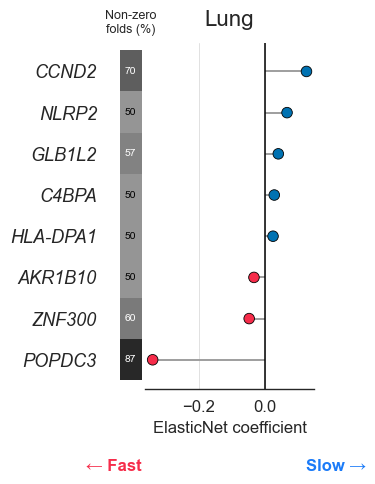

Loaded /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_elasticnet_coefficient_summary_lung.csv
Lung ElasticNet: 30 completed folds; plotted top 8 genes with >= 50% non-zero-fold frequency; saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/Figure2_ElasticNet_Coefficients_lung.png


In [10]:
lung_en_summary_file = PROC_DIR / "growth_elasticnet_coefficient_summary_lung.csv"
lung_en_summary = pd.read_csv(lung_en_summary_file)

EN_TOP_N = 12

lung_en_plot = RESULTS_DIR / "Figure2_ElasticNet_Coefficients_lung.png"
lung_en_top = plot_elasticnet_cv_coefficients(
    lung_en_summary,
    cohort="Lung",
    output_path=lung_en_plot,
    top_n=EN_TOP_N,
)

n_lung_en_folds = int(lung_en_summary["n_completed_folds"].iloc[0])
print(f"Loaded {lung_en_summary_file}")
print(f"Lung ElasticNet: {n_lung_en_folds} completed folds; plotted top {len(lung_en_top)} genes with >= {EN_MIN_NONZERO_FREQUENCY:.0%} non-zero-fold frequency; saved {lung_en_plot}")

### Comparison of EN and RF

In [11]:
# Overlap between top-20 ElasticNet and top-20 Random Forest genes, per cohort
import pandas as pd

EN_RF_TOP_N = 20

for cohort in ("breast", "lung"):
    en_summary = pd.read_csv(PROC_DIR / f"growth_elasticnet_coefficient_summary_{cohort}.csv")
    rf_importance = pd.read_csv(PROC_DIR / f"growth_rf_gene_importance_{cohort}.csv", index_col=0)

    en_top = set(en_summary.nlargest(EN_RF_TOP_N, "abs_mean_standardized_coefficient")["Gene"])
    rf_top = set(rf_importance.nlargest(EN_RF_TOP_N, "mean_gini_importance").index)
    shared_top = sorted(en_top & rf_top)

    print(f"{cohort.capitalize()}:")
    print(f"  ElasticNet top {EN_RF_TOP_N}: {sorted(en_top)}")
    print(f"  Random Forest top {EN_RF_TOP_N}: {sorted(rf_top)}")
    print(f"  Shared ({len(shared_top)} of {EN_RF_TOP_N}): {shared_top}")
    print()

Breast:
  ElasticNet top 20: ['ACTA2', 'ACTG2', 'ANPEP', 'AQP3', 'CALML5', 'COL6A1', 'CRABP1', 'CRISP3', 'CXCL14', 'DEFB1', 'FDCSP', 'H4C13', 'IFITM1', 'IGFBP5', 'KRT5', 'LDHB', 'SFRP1', 'SPARC', 'SPTSSB', 'VGLL1']
  Random Forest top 20: ['ACTA2', 'ACTG2', 'ANPEP', 'AQP3', 'CALML5', 'COL1A2', 'CXCL14', 'EFHD1', 'FDCSP', 'GPNMB', 'H2BC10', 'H4C13', 'IFITM1', 'IGFBP5', 'IGFBP7', 'KRT23', 'LDHB', 'PDGFRA', 'SERPINA3', 'TIMP3']
  Shared (11 of 20): ['ACTA2', 'ACTG2', 'ANPEP', 'AQP3', 'CALML5', 'CXCL14', 'FDCSP', 'H4C13', 'IFITM1', 'IGFBP5', 'LDHB']

Lung:
  ElasticNet top 20: ['AKR1B10', 'C4BPA', 'CCNA1', 'CCND2', 'CD74', 'CLIC5', 'FCGBP', 'GLB1L2', 'HLA-F', 'HOXB9', 'LCP1', 'MFSD6L', 'MGP', 'NLRP2', 'NYNRIN', 'POPDC3', 'SERPINE2', 'TNNC1', 'ZFP37', 'ZNF300']
  Random Forest top 20: ['CCNA1', 'CCND2', 'FCGBP', 'FHOD3', 'FRMD3', 'GLB1L2', 'MFSD6L', 'MYOZ1', 'NR0B1', 'NRIP3', 'PCDHB13', 'PODXL2', 'POPDC3', 'RYR3', 'SERPINE2', 'SHROOM2', 'TMEM156', 'TNNC1', 'VEGFC', 'ZFP37']
  Shared (9 of 2

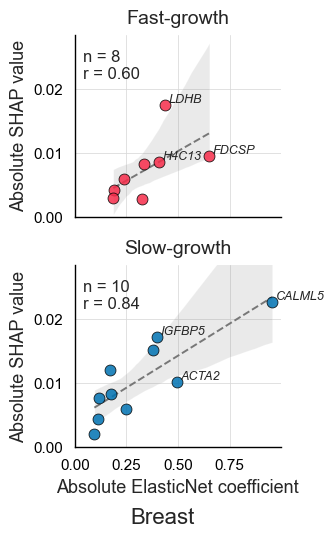

Loaded /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_elasticnet_coefficient_summary_breast.csv
Loaded /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_rf_shap_summary_breast.csv
Breast comparison: 18 genes with >= 50% ElasticNet non-zero-fold frequency; saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/Figure2_EN_RF_Comparison_breast.png


In [12]:
# Breast: ElasticNet coefficients versus Random Forest SHAP importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

EN_RF_MIN_NONZERO_FREQUENCY = 0.50
EN_RF_TOP_LABELS_PER_DIRECTION = 3


def load_en_rf_comparison(cohort, min_nonzero_frequency=EN_RF_MIN_NONZERO_FREQUENCY):
    en_file = PROC_DIR / f"growth_elasticnet_coefficient_summary_{cohort}.csv"
    shap_file = PROC_DIR / f"growth_rf_shap_summary_{cohort}.csv"

    en = pd.read_csv(en_file)
    rf_shap = pd.read_csv(shap_file)
    en = en.loc[en["nonzero_frequency"] >= min_nonzero_frequency].copy()

    comparison = en.merge(
        rf_shap[["Gene", "mean_abs_shap_all_test_predictions"]],
        on="Gene",
        how="inner",
        validate="one_to_one",
    )
    comparison["Abs_Coefficient"] = comparison["mean_standardized_coefficient"].abs()
    comparison["RF_SHAP_Importance"] = comparison["mean_abs_shap_all_test_predictions"]
    comparison["Growth_Direction"] = np.where(
        comparison["mean_standardized_coefficient"] < 0,
        "Fast growth",
        "Slow growth",
    )
    return comparison, en_file, shap_file


def plot_en_rf_comparison(
    comparison, cohort_label, output_path,
    top_labels=EN_RF_TOP_LABELS_PER_DIRECTION,
):
    direction_settings = [
        ("Fast growth", "#f62c4a", "Fast-growth"),
        ("Slow growth", "#0072B2", "Slow-growth"),
    ]
    fig, axes = plt.subplots(2, 1, figsize=(3.5, 5.5), sharex=True, sharey=True)

    for ax, (direction, color, title) in zip(axes, direction_settings):
        subset = comparison.loc[comparison["Growth_Direction"] == direction].copy()
        x = subset["Abs_Coefficient"]
        y = subset["RF_SHAP_Importance"]
        can_fit = len(subset) >= 3 and x.nunique() > 1 and y.nunique() > 1

        if can_fit:
            sns.regplot(
                data=subset,
                x="Abs_Coefficient",
                y="RF_SHAP_Importance",
                ax=ax,
                scatter=False,
                ci=95,
                color="#777777",
                line_kws={"linewidth": 1.4, "linestyle": "--"},
            )
            r_value = x.corr(y)
            statistic = f"n = {len(subset)}\nr = {r_value:.2f}"
        else:
            statistic = f"n = {len(subset)}\nr not estimated"

        ax.scatter(
            x, y, s=62, color=color, alpha=0.85,
            edgecolor="black", linewidth=0.6, zorder=3,
        )

        if not subset.empty:
            subset["Consensus_Rank"] = (
                subset["Abs_Coefficient"].rank(pct=True)
                + subset["RF_SHAP_Importance"].rank(pct=True)
            )
            labelled = subset.nlargest(min(top_labels, len(subset)), "Consensus_Rank")
            x_offset = max(comparison["Abs_Coefficient"].max() * 0.018, 0.002)
            y_offset = max(comparison["RF_SHAP_Importance"].max() * 0.018, 0.0001)
            for _, row in labelled.iterrows():
                ax.text(
                    row["Abs_Coefficient"] + x_offset,
                    row["RF_SHAP_Importance"] + y_offset,
                    row["Gene"], fontsize=9, fontstyle="italic",
                )

        ax.set_title(title, fontsize=14, pad=8)
        ax.text(0.04, 0.92, statistic, transform=ax.transAxes, fontsize=12, va="top")
        ax.set_ylabel("Absolute SHAP value", fontsize=12)
        ax.set_ylim(bottom=0)
        ax.grid(color="#D9D9D9", linewidth=0.7, alpha=0.8)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_color("black")
        ax.spines["left"].set_color("black")
        ax.tick_params(labelsize=11, colors="black")

    axes[0].set_xlabel("", fontsize=13)
    axes[0].set_ylabel("Absolute SHAP value", fontsize=13)
    axes[1].set_xlabel("Absolute ElasticNet coefficient", fontsize=13)
    axes[1].set_ylabel("Absolute SHAP value", fontsize=13)
    axes[1].set_xlim(left=0)
    fig.suptitle(cohort_label, fontsize=16, y=0.005)
    plt.tight_layout()
    plt.savefig(output_path, dpi=600, bbox_inches="tight")
    plt.savefig(output_path.with_suffix(".pdf"), bbox_inches="tight")
    plt.show()


breast_en_rf, breast_en_file, breast_shap_file = load_en_rf_comparison("breast")
breast_en_rf_plot = RESULTS_DIR / "Figure2_EN_RF_Comparison_breast.png"
plot_en_rf_comparison(breast_en_rf, "Breast", breast_en_rf_plot)
print(f"Loaded {breast_en_file}")
print(f"Loaded {breast_shap_file}")
print(
    f"Breast comparison: {len(breast_en_rf)} genes with >= "
    f"{EN_RF_MIN_NONZERO_FREQUENCY:.0%} ElasticNet non-zero-fold frequency; "
    f"saved {breast_en_rf_plot}"
)


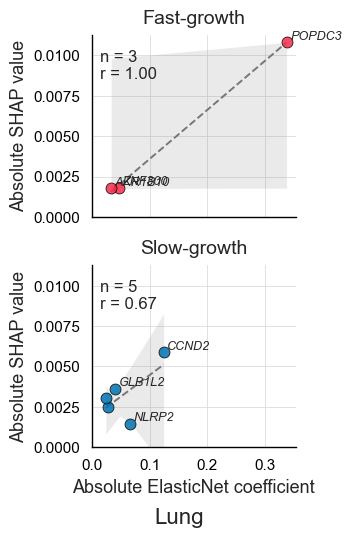

Loaded /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_elasticnet_coefficient_summary_lung.csv
Loaded /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_rf_shap_summary_lung.csv
Lung comparison: 8 genes with >= 50% ElasticNet non-zero-fold frequency; saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/Figure2_EN_RF_Comparison_lung.png


In [13]:
# Lung: ElasticNet coefficients versus Random Forest SHAP importance
lung_en_rf, lung_en_file, lung_shap_file = load_en_rf_comparison("lung")
lung_en_rf_plot = RESULTS_DIR / "Figure2_EN_RF_Comparison_lung.png"
plot_en_rf_comparison(lung_en_rf, "Lung", lung_en_rf_plot)
print(f"Loaded {lung_en_file}")
print(f"Loaded {lung_shap_file}")
print(
    f"Lung comparison: {len(lung_en_rf)} genes with >= "
    f"{EN_RF_MIN_NONZERO_FREQUENCY:.0%} ElasticNet non-zero-fold frequency; "
    f"saved {lung_en_rf_plot}"
)


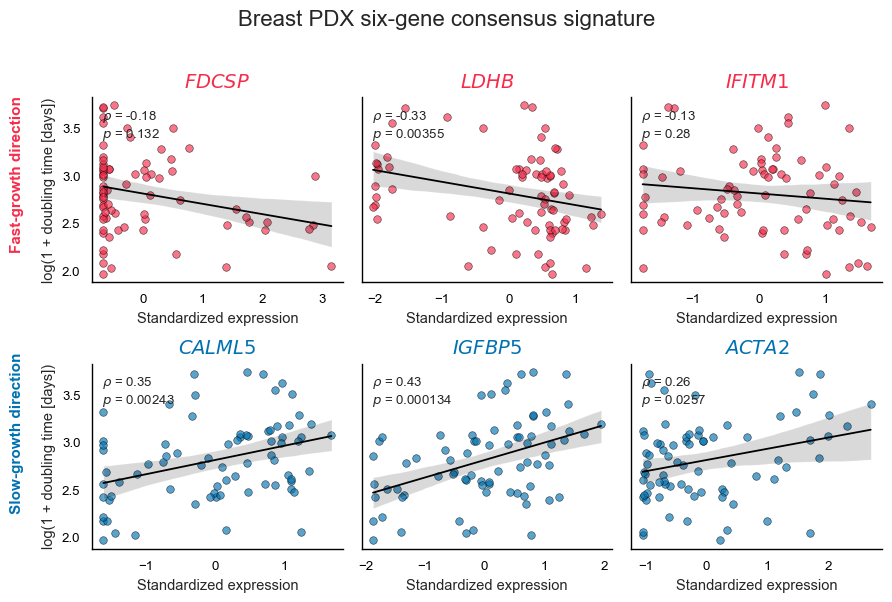

,Gene,Growth_Direction,n,Spearman_rho,p_value
0,FDCSP,Fast growth,75,-0.175367,0.132348
1,LDHB,Fast growth,75,-0.332622,0.003549
2,IFITM1,Fast growth,75,-0.126281,0.280328
3,CALML5,Slow growth,75,0.345046,0.002432
4,IGFBP5,Slow growth,75,0.426840,0.000134
5,ACTA2,Slow growth,75,0.257608,0.025662


Loaded /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/rna_doubling_time_merged_breast.csv
Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/Figure2_Breast_Six_Gene_Expression_Doubling_Time.png


In [14]:
# Breast: expression of the six EN-RF consensus genes versus doubling time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Use the exact input matrix used by the current breast ML workflow.
expression_file = PROC_DIR / "rna_doubling_time_merged_breast.csv"
target_col = "doubling_time_days"
gene_groups = {
    "Fast growth": ["FDCSP", "LDHB", "IFITM1"],
    "Slow growth": ["CALML5", "IGFBP5", "ACTA2"],
}
direction_colors = {"Fast growth": "#f62c4a", "Slow growth": "#0072B2"}
genes = [gene for group in gene_groups.values() for gene in group]

df_six = pd.read_csv(expression_file, index_col=0)
missing = [column for column in [target_col, *genes] if column not in df_six.columns]
if missing:
    raise ValueError(f"Missing required columns in {expression_file}: {missing}")

plot_df = df_six[[target_col, *genes]].apply(pd.to_numeric, errors="coerce").copy()
plot_df["log_doubling_time"] = np.log1p(plot_df[target_col])
for gene in genes:
    gene_sd = plot_df[gene].std(ddof=0)
    if not np.isfinite(gene_sd) or gene_sd == 0:
        raise ValueError(f"Cannot standardize {gene}: zero or invalid standard deviation")
    plot_df[f"{gene}_z"] = (plot_df[gene] - plot_df[gene].mean()) / gene_sd

fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharey=True)
statistics_rows = []

for row_index, (direction, direction_genes) in enumerate(gene_groups.items()):
    color = direction_colors[direction]
    for col_index, gene in enumerate(direction_genes):
        ax = axes[row_index, col_index]
        gene_df = plot_df[[f"{gene}_z", "log_doubling_time"]].dropna()
        rho, p_value = stats.spearmanr(
            gene_df[f"{gene}_z"], gene_df["log_doubling_time"]
        )
        statistics_rows.append({
            "Gene": gene, "Growth_Direction": direction,
            "n": len(gene_df), "Spearman_rho": rho, "p_value": p_value,
        })

        sns.regplot(
            data=gene_df, x=f"{gene}_z", y="log_doubling_time", ax=ax, ci=95,
            scatter_kws={
                "s": 30, "alpha": 0.65, "color": color,
                "edgecolor": "black", "linewidths": 0.45,
            },
            line_kws={"color": "black", "linewidth": 1.3},
        )
        ax.set_title(rf"$\mathit{{{gene}}}$", fontsize=14, color=color, pad=7)
        ax.text(
            0.04, 0.94, rf"$\rho$ = {rho:.2f}" + "\n" + rf"$p$ = {p_value:.3g}",
            transform=ax.transAxes, ha="left", va="top", fontsize=9.5,
        )
        ax.set_xlabel("Standardized expression", fontsize=10.5)
        ax.set_ylabel("log(1 + doubling time [days])" if col_index == 0 else "", fontsize=10.5)
        ax.tick_params(labelsize=9.5, colors="black", width=1)
        ax.spines["bottom"].set_color("black")
        ax.spines["left"].set_color("black")
        ax.spines["bottom"].set_linewidth(1)
        ax.spines["left"].set_linewidth(1)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(False)

fig.text(0.015, 0.72, "Fast-growth direction", rotation=90, color=direction_colors["Fast growth"],
         fontsize=11, va="center", fontweight="bold")
fig.text(0.015, 0.29, "Slow-growth direction", rotation=90, color=direction_colors["Slow growth"],
         fontsize=11, va="center", fontweight="bold")
fig.suptitle("Breast PDX six-gene consensus signature", fontsize=16, y=0.995)
plt.tight_layout(rect=[0.035, 0, 1, 0.97])

six_gene_plot = RESULTS_DIR / "Figure2_Breast_Six_Gene_Expression_Doubling_Time.png"
plt.savefig(six_gene_plot, dpi=600, bbox_inches="tight")
plt.savefig(six_gene_plot.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

six_gene_statistics = pd.DataFrame(statistics_rows)
display(six_gene_statistics)
print(f"Loaded {expression_file}")
print(f"Saved {six_gene_plot}")

Breast: 25 fast and 25 slow models; ranked 14,070 genes from rna_doubling_time_merged_breast.csv


2026-08-10 17:53:16,954 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Lung: 9 fast and 9 slow models; ranked 17,493 genes from rna_doubling_time_merged_lung.csv


2026-08-10 17:54:33,972 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


2026-08-10 17:54:45,782 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


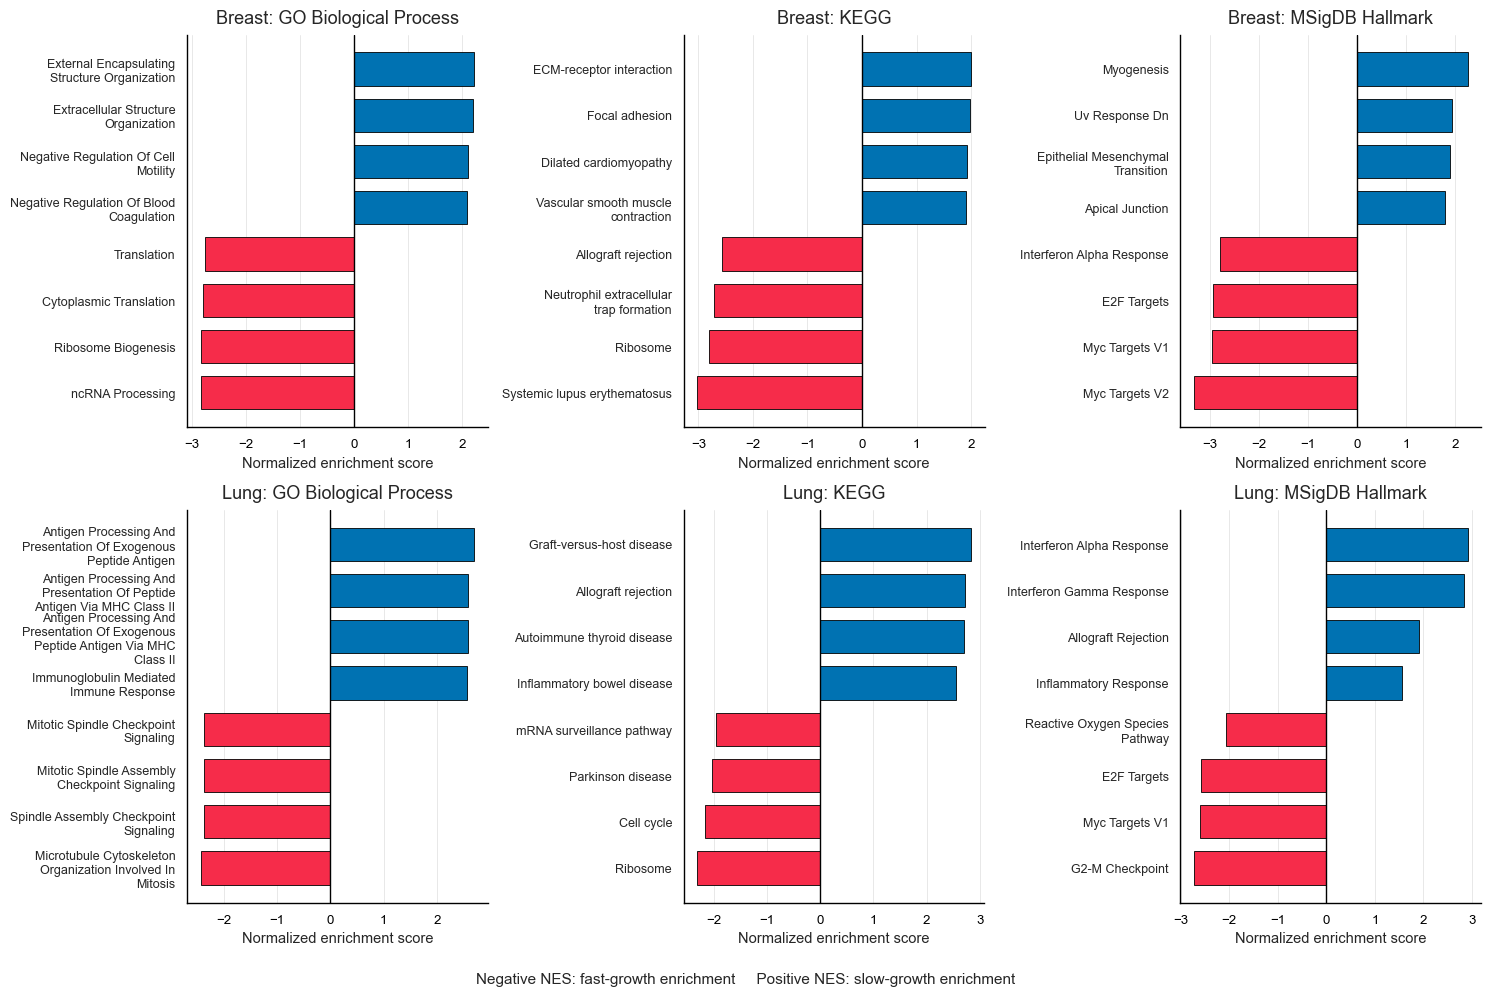

Saved GSEA figure: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/Figure3_GSEA_GO_KEGG_Hallmark_breast_lung.png


,Term,NES_breast,FDR_breast,NES_lung,FDR_lung,Collection,direction_concordant,best_FDR
2189,Ribosome,-2.804656,0.0,-2.314,0.0,KEGG,True,0.0
2481,Myc Targets V1,-2.951381,0.0,-2.600455,0.0,MSigDB Hallmark,True,0.0
2482,E2F Targets,-2.942198,0.0,-2.581543,0.0,MSigDB Hallmark,True,0.0
2485,G2-M Checkpoint,-2.294026,0.0,-2.724964,0.0,MSigDB Hallmark,True,0.0
3,Translation (GO:0006412),-2.748864,0.0,-2.295192,0.000095,GO Biological Process,True,0.000095
1,Ribosome Biogenesis (GO:0042254),-2.834897,0.0,-2.293803,0.000116,GO Biological Process,True,0.000116
6,rRNA Processing (GO:0006364),-2.654711,0.0,-2.260098,0.000137,GO Biological Process,True,0.000137
5,Ribonucleoprotein Complex Biogenesis (GO:0022613),-2.706011,0.0,-2.235511,0.000186,GO Biological Process,True,0.000186
2488,mTORC1 Signaling,-2.001375,0.000578,-1.982657,0.000087,MSigDB Hallmark,True,0.000578
23,Mitochondrial Gene Expression (GO:0140053),-2.229512,0.002331,-2.31086,0.000077,GO Biological Process,True,0.002331


In [15]:
# Breast and lung: ranked pathway enrichment using the current ML input matrices
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gseapy as gp
import textwrap
from scipy import stats

FAST_QUANTILE = 0.33
SLOW_QUANTILE = 0.67
GSEA_PERMUTATIONS = 5000
GSEA_MIN_SIZE = 15
GSEA_MAX_SIZE = 500
GSEA_FDR_THRESHOLD = 0.05
GSEA_TOP_PER_DIRECTION = 4
GSEA_SEED = 42

cohort_files = {
    "Breast": PROC_DIR / "rna_doubling_time_merged_breast.csv",
    "Lung": PROC_DIR / "rna_doubling_time_merged_lung.csv",
}
gene_set_libraries = {
    "GO Biological Process": "GO_Biological_Process_2023",
    "KEGG": "KEGG_2021_Human",
    "MSigDB Hallmark": "MSigDB_Hallmark_2020",
}


def build_growth_rank(cohort, expression_file):
    """Rank every input gene by Welch t: slow-growth expression minus fast-growth expression."""
    data = pd.read_csv(expression_file, index_col=0)
    target_col = "doubling_time_days"
    if target_col not in data.columns:
        raise ValueError(f"Missing {target_col} in {expression_file}")

    log_dt = np.log1p(pd.to_numeric(data[target_col], errors="raise"))
    fast_cutoff = log_dt.quantile(FAST_QUANTILE)
    slow_cutoff = log_dt.quantile(SLOW_QUANTILE)
    fast_mask = log_dt <= fast_cutoff
    slow_mask = log_dt >= slow_cutoff

    expression = data.drop(columns=target_col).apply(pd.to_numeric, errors="coerce")
    test = stats.ttest_ind(
        expression.loc[slow_mask].to_numpy(dtype=float),
        expression.loc[fast_mask].to_numpy(dtype=float),
        axis=0, equal_var=False, nan_policy="omit",
    )
    rank_table = pd.DataFrame({
        "Gene": expression.columns,
        "ranking_statistic": test.statistic,
        "unadjusted_p_value": test.pvalue,
        "mean_expression_slow": expression.loc[slow_mask].mean(axis=0).to_numpy(),
        "mean_expression_fast": expression.loc[fast_mask].mean(axis=0).to_numpy(),
    })
    rank_table["mean_difference_slow_minus_fast"] = (
        rank_table["mean_expression_slow"] - rank_table["mean_expression_fast"]
    )
    rank_table = (
        rank_table.replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["ranking_statistic"])
        .sort_values("ranking_statistic", ascending=False)
        .reset_index(drop=True)
    )

    cohort_key = cohort.lower()
    rank_table.to_csv(RESULTS_DIR / f"growth_pathway_gene_ranking_{cohort_key}.csv", index=False)
    rank_table[["Gene", "ranking_statistic"]].to_csv(
        RESULTS_DIR / f"growth_pathway_gene_ranking_{cohort_key}.rnk",
        sep="\t", index=False, header=False,
    )
    print(
        f"{cohort}: {fast_mask.sum()} fast and {slow_mask.sum()} slow models; "
        f"ranked {len(rank_table):,} genes from {expression_file.name}"
    )
    return rank_table


rank_tables = {
    cohort: build_growth_rank(cohort, expression_file)
    for cohort, expression_file in cohort_files.items()
}

# Positive NES means enrichment in slow-growing PDXs; negative NES means fast-growing PDXs.
gsea_results = {}
for cohort, rank_table in rank_tables.items():
    for collection_label, library_name in gene_set_libraries.items():
        enrichment = gp.prerank(
            rnk=rank_table[["Gene", "ranking_statistic"]],
            gene_sets=library_name,
            min_size=GSEA_MIN_SIZE, max_size=GSEA_MAX_SIZE,
            permutation_num=GSEA_PERMUTATIONS,
            threads=4, seed=GSEA_SEED,
            outdir=None, no_plot=True, verbose=False,
        )
        result = enrichment.res2d.copy()
        result["Cohort"] = cohort
        result["Collection"] = collection_label
        result["Growth_Direction"] = np.where(
            result["NES"] > 0, "Slow growth", "Fast growth"
        )
        gsea_results[(cohort, collection_label)] = result
        output_name = collection_label.lower().replace(" ", "_")
        result.to_csv(
            RESULTS_DIR / f"growth_gsea_{cohort.lower()}_{output_name}.csv", index=False
        )


def select_pathways_for_plot(result):
    significant = result.loc[result["FDR q-val"] < GSEA_FDR_THRESHOLD].copy()
    positive = (
        significant.loc[significant["NES"] > 0]
        .sort_values(["FDR q-val", "NES"], ascending=[True, False])
        .head(GSEA_TOP_PER_DIRECTION)
    )
    negative = (
        significant.loc[significant["NES"] < 0]
        .sort_values(["FDR q-val", "NES"], ascending=[True, True])
        .head(GSEA_TOP_PER_DIRECTION)
    )
    return pd.concat([negative, positive]).sort_values("NES")


def format_pathway_name(term, collection_label):
    term = str(term).split(" (GO:")[0]
    if collection_label == "MSigDB Hallmark":
        term = term.replace("HALLMARK_", "").replace("_", " " ).title()
    return "\n".join(textwrap.wrap(term, width=28))


color_fast = "#f62c4a"
color_slow = "#0072B2"
fig, axes = plt.subplots(2, 3, figsize=(15, 10), squeeze=False)
for row_index, cohort in enumerate(cohort_files):
    for col_index, collection_label in enumerate(gene_set_libraries):
        ax = axes[row_index, col_index]
        plot_data = select_pathways_for_plot(gsea_results[(cohort, collection_label)])
        if plot_data.empty:
            ax.text(
                0.5, 0.5, f"No pathways at FDR < {GSEA_FDR_THRESHOLD:.2f}",
                transform=ax.transAxes, ha="center", va="center", fontsize=11,
            )
            ax.set_yticks([])
        else:
            labels = [
                format_pathway_name(term, collection_label) for term in plot_data["Term"]
            ]
            colors = [color_slow if nes > 0 else color_fast for nes in plot_data["NES"]]
            ax.barh(
                labels, plot_data["NES"], color=colors,
                edgecolor="black", linewidth=0.6, height=0.72,
            )
        ax.axvline(0, color="black", linewidth=1)
        ax.set_title(f"{cohort}: {collection_label}", fontsize=13, pad=8)
        ax.set_xlabel("Normalized enrichment score", fontsize=10.5)
        ax.tick_params(axis="x", labelsize=9.5, colors="black")
        ax.tick_params(axis="y", labelsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_color("black")
        ax.spines["left"].set_color("black")
        ax.grid(axis="x", color="#D9D9D9", linewidth=0.6, alpha=0.7)
        ax.set_axisbelow(True)

fig.text(
    0.5, 0.012,
    "Negative NES: fast-growth enrichment     Positive NES: slow-growth enrichment",
    ha="center", fontsize=11,
)
plt.tight_layout(rect=[0, 0.035, 1, 1])
gsea_plot = RESULTS_DIR / "Figure3_GSEA_GO_KEGG_Hallmark_breast_lung.png"
plt.savefig(gsea_plot, dpi=600, bbox_inches="tight")
plt.savefig(gsea_plot.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

# Save pathways observed in both cohorts, including direction concordance.
cross_cohort_rows = []
for collection_label in gene_set_libraries:
    breast = gsea_results[("Breast", collection_label)][
        ["Term", "NES", "FDR q-val"]
    ].rename(columns={"NES": "NES_breast", "FDR q-val": "FDR_breast"})
    lung = gsea_results[("Lung", collection_label)][
        ["Term", "NES", "FDR q-val"]
    ].rename(columns={"NES": "NES_lung", "FDR q-val": "FDR_lung"})
    shared = breast.merge(lung, on="Term", how="inner", validate="one_to_one")
    shared["Collection"] = collection_label
    shared["direction_concordant"] = np.sign(shared["NES_breast"]) == np.sign(shared["NES_lung"])
    shared["best_FDR"] = shared[["FDR_breast", "FDR_lung"]].max(axis=1)
    cross_cohort_rows.append(shared)

cross_cohort_gsea = (
    pd.concat(cross_cohort_rows, ignore_index=True)
    .sort_values(["direction_concordant", "best_FDR"], ascending=[False, True])
)
cross_cohort_gsea.to_csv(
    RESULTS_DIR / "growth_gsea_cross_cohort_concordance.csv", index=False
)
print(f"Saved GSEA figure: {gsea_plot}")
display(cross_cohort_gsea.head(20))


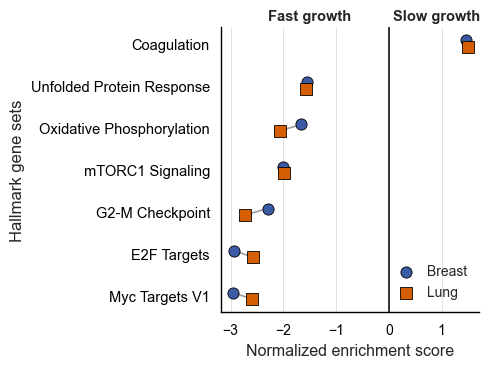

,Pathway,NES_breast,FDR_breast,NES_lung,FDR_lung
0,Myc Targets V1,-2.951381,0.000000,-2.600455,0.000000
1,E2F Targets,-2.942198,0.000000,-2.581543,0.000000
2,G2-M Checkpoint,-2.294026,0.000000,-2.724964,0.000000
3,mTORC1 Signaling,-2.001375,0.000578,-1.982657,0.000087
4,Oxidative Phosphorylation,-1.663710,0.007770,-2.053634,0.000091
5,Unfolded Protein Response,-1.543758,0.018224,-1.564774,0.012562
6,Coagulation,1.467042,0.038746,1.493797,0.037032


Loaded /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/growth_gsea_cross_cohort_concordance.csv
Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/Figure3_Main_Shared_Hallmark_NES.png


In [16]:
# Main-figure panel: pathways concordantly enriched in breast and lung PDXs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

concordance_file = RESULTS_DIR / "growth_gsea_cross_cohort_concordance.csv"
shared_pathways = pd.read_csv(concordance_file)

# Hallmark is used for the main panel because it is compact and less redundant than GO.
# Selection is objective: same NES direction and FDR < 0.05 in both cohorts.
main_pathways = shared_pathways.loc[
    (shared_pathways["Collection"] == "MSigDB Hallmark")
    & shared_pathways["direction_concordant"].astype(bool)
    & (shared_pathways["FDR_breast"] < 0.05)
    & (shared_pathways["FDR_lung"] < 0.05)
].copy()
if main_pathways.empty:
    raise ValueError("No concordant Hallmark pathways pass FDR < 0.05 in both cohorts")

main_pathways["mean_NES"] = main_pathways[["NES_breast", "NES_lung"]].mean(axis=1)
main_pathways = main_pathways.sort_values("mean_NES", ascending=True).reset_index(drop=True)
main_pathways["Pathway"] = (
    main_pathways["Term"].str.replace("HALLMARK_", "", regex=False)
    .str.replace("_", " ", regex=False)
)

y_position = np.arange(len(main_pathways))
breast_color = "#3B5BA5"
lung_color = "#D55E00"
fast_color = "#f62c4a"
slow_color = "#0072B2"

fig, ax = plt.subplots(figsize=(5, 4))
marker_offset = 0.075
for y, breast_nes, lung_nes in zip(
    y_position, main_pathways["NES_breast"], main_pathways["NES_lung"]
):
    ax.plot(
        [breast_nes, lung_nes], [y + marker_offset, y - marker_offset], color="#9E9E9E",
        linewidth=1.2, zorder=1,
    )

ax.scatter(
    main_pathways["NES_breast"], y_position + marker_offset, s=65, marker="o",
    color=breast_color, edgecolor="black", linewidth=0.6, label="Breast", zorder=3,
)
ax.scatter(
    main_pathways["NES_lung"], y_position - marker_offset, s=65, marker="s",
    color=lung_color, edgecolor="black", linewidth=0.6, label="Lung", zorder=3,
)
ax.axvline(0, color="black", linewidth=1.1, zorder=2)
ax.set_yticks(y_position)
ax.set_yticklabels(main_pathways["Pathway"], fontsize=10.5)
ax.set_xlabel("Normalized enrichment score", fontsize=11.5)
# ax.set_title("Shared Hallmark pathway enrichment", fontsize=14, pad=22)
ax.text(
    0.18, 1.015, "Fast growth", transform=ax.transAxes,
    ha="left", va="bottom", fontsize=10.5, fontweight="bold",
)
ax.text(
    1.005, 1.015, "Slow growth", transform=ax.transAxes,
    ha="right", va="bottom", fontsize=10.5, fontweight="bold",
)
ax.legend(loc="lower right", frameon=False, fontsize=10, handletextpad=0.5)
ax.grid(axis="x", color="#D9D9D9", linewidth=0.7, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")
ax.tick_params(axis="x", labelsize=10, colors="black")
ax.tick_params(axis="y", colors="black")
ax.set_ylabel("Hallmark gene sets", fontsize=12)

# fig.text(
#     0.5, 0.012, "Concordant direction; FDR < 0.05 in both cohorts",
#     ha="center", va="bottom", fontsize=8.5, color="#555555",
# )
plt.tight_layout(rect=[0, 0.055, 1, 1])
main_pathway_plot = RESULTS_DIR / "Figure3_Main_Shared_Hallmark_NES.png"
plt.savefig(main_pathway_plot, dpi=600, bbox_inches="tight")
plt.savefig(main_pathway_plot.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

display(main_pathways[[
    "Pathway", "NES_breast", "FDR_breast", "NES_lung", "FDR_lung"
]])
print(f"Loaded {concordance_file}")
print(f"Saved {main_pathway_plot}")
